<a href="https://colab.research.google.com/github/martintphh/NBodySim/blob/main/JESS_NeutronStar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exercise of NSs**

---



# Disclaimer: Some codes are not written in a good way—I'm just lazy. Please don't use it as a learning reference for coding!


# 1. A Simple Model for **npe** Matter (Non-interacting Fermi Gases)

We model neutron-star core matter as a mixture of **neutrons (n)**, **protons (p)**, and **electrons (e)**:
- baryons (n,p): **non-relativistic** degenerate Fermi gases  
- electrons: **ultra-relativistic** degenerate Fermi gas  
- neutrinos escape: **$\mu_\nu = 0$** (“transparent to neutrinos”)

We will work mostly in units with $\hbar=c=1$ when convenient, but you should keep track of units in numerical estimates.

---

## Constants / reference values

- Nuclear saturation density:  
  $$
  n_0 = 0.16~\mathrm{fm^{-3}}
  $$
- $\hbar c \simeq 197.33~\mathrm{MeV\,fm}$
- Nucleon mass:  
  $$
  m_b c^2 \simeq 939~\mathrm{MeV}
  $$
- Electron mass (for checking ultrarelativistic limit):  
  $$
  m_e c^2 \simeq 0.511~\mathrm{MeV}
  $$
- Boltzmann constant:  
  $$
  k_B \simeq 8.617\times 10^{-11}~\mathrm{MeV/K}
  $$

For a degenerate Fermi gas (spin 1/2),
$$
n_i = \frac{p_{F,i}^3}{3\pi^2\hbar^3},
\qquad
p_{F,i} = \hbar(3\pi^2 n_i)^{1/3}.
$$

---


# Part A — Degeneracy and “Cold” Matter

Considering pure neutron matter at number density $n_n=n_0$. The neutron Fermi momentum is
   $$
   p_{F,n}(n_0)=\hbar(3\pi^2 n_0)^{1/3}.
   $$
Assuming neutrons are **non-relativistic**:
$$
E_{F,n}=\frac{p_{F,n}^2}{2m_b}.
$$

1. Compute $E_{F,n}(n_0)$ in MeV.
2. Define the **Fermi temperature**
   $$
   T_{F,n} \equiv \frac{E_{F,n}}{k_B}.
   $$
   Estimate $T_{F,n}$ in Kelvin.
3. Explain what “**cold**” means in neutron-star physics, in terms of the ratio
   $$
   \frac{T}{T_F}\,.
   $$

*(Hint: typical mature neutron-star core temperatures are far below $10^{10}\,\mathrm{K}$.)*

---

In [ ]:
# you can calculate the solution here:

# Part B — Chemical Potentials and Energy Density

In this model, chemical potentials are approximated by
- baryons (non-relativistic):
  $$
  \mu_x = m_x c^2 + E_{F,x}, \qquad x=n,p
  $$
- electrons (ultra-relativistic):
  $$
  \mu_e = E_{F,e} = p_{F,e}c = \hbar c\,(3\pi^2 n_e)^{1/3}.
  $$

## Problem B1: Build the total energy density $\varepsilon$
As the chemical potenials are given by the partial derivatives of the energy density with respect to the individual number densities (**$\mu_i = \partial \epsilon/\partial n_i$**), please derive the energy density for each species:

- non-relativistic fermions:
  $$
  \varepsilon_x = m_x c^2\,n_x + \frac{3}{5}n_x E_{F,x},\qquad x=n,p
  $$
- ultra-relativistic fermions:
  $$
  \varepsilon_e = \frac{3}{4}n_e E_{F,e}.
  $$

Then the total energy density can be written as
   $$
   \boxed{
   \varepsilon
   =
   (m_n n_n + m_p n_p)c^2
   +\frac{3}{5}(n_nE_{F,n}+n_pE_{F,p})
   +\frac{3}{4}n_eE_{F,e}
   }.
   $$

---

# Part C — Estimate the proton fraction

Neutron-star matter is in weak (β) equilibrium via Urca reactions:
$$
n \to p + e^- + \nu_e,\qquad
p + e^- \to n + \nu_e,
$$
and neutrinos escape, so $\mu_{\nu_e}=0$. The chemical equilibrium implies
   $$
   \boxed{\mu_n = \mu_p + \mu_e.}
   $$
While the charge neutrality implies
   $$
   \boxed{n_p = n_e.}
   $$

## Question: can you estimate the proton fraction at nuclear saturation density?

Let the **baryon number density** and the **proton fraction** be
$$
n \equiv n_n + n_p,
\qquad
x_p \equiv \frac{n_p}{n}.
$$

Assume:
- $m_n=m_p=m_b$
- $x_p\ll 1$ (neutron rich)
- $n=n_0$


After you obtain the results, you can answer the **conceptual question:** why we call it neutron star?

---

# Final remark

This provides us with the input physics we need in order to build a star. The model may
not be particularly realistic, but it achieves two things. It gives us a rough idea of what
to expect and also introduces the key building blocks of a more detailed description. In
order to improve the model, we must account for particle interactions—the effect that the
presence of the protons has on the neutrons, and so on. This is far from straightforward
since it requires knowledge of the nuclear N-body interactions at extreme densities. More exotic particles may also emerge in the cores of neutron stars. In that situation, one must consider additional chemical equilibrium relations, as well as include the effects of particle interactions.

---

# 2. Relativistic Fluid Conservation Laws (Perfect Fluid)

This sheet explains how the two key equations for a perfect fluid follow from
$$\nabla_\beta T^{\alpha\beta}=0$$
by taking **projections parallel and perpendicular to** the 4-velocity $u^\alpha$.
You may treat the derivations below as “given” and focus on understanding each step.

---

## Setup and Definitions

A **perfect fluid** has stress-energy tensor
$$
T^{\alpha\beta}=(\varepsilon+p)u^\alpha u^\beta + p\,g^{\alpha\beta},
$$
where
- $\varepsilon$ is the total energy density in the local rest frame,
- $p$ is the pressure,
- $u^\alpha$ is the 4-velocity with normalization
$$
u_\alpha u^\alpha = -1,
$$
- $g^{\alpha\beta}$ is the metric (signature $-+++)$.

Define the projector orthogonal to $u^\alpha$:
$$
q^{\alpha}{}_{\gamma} \equiv \delta^{\alpha}{}_{\gamma}+u^\alpha u_\gamma,
\qquad
q^{\alpha\beta}=g^{\alpha\beta}+u^\alpha u^\beta.
$$

**Useful identities (you may use without proof):**
1. Metric compatibility: $\nabla_\beta g^{\alpha\beta}=0$.
2. From $u_\alpha u^\alpha=-1$, taking $\nabla_\beta$ gives:
   $$
   u_\alpha \nabla_\beta u^\alpha = 0.
   $$
3. $q^{\alpha}{}_{\gamma}u^\gamma = 0$ (it projects orthogonal to $u^\alpha$).

---

# Part A — Warm-up: What does projection mean?

### A1
Show that any vector $A^\alpha$ can be decomposed as
$$
A^\alpha = -(u_\gamma A^\gamma)\,u^\alpha + q^{\alpha}{}_{\gamma}A^\gamma.
$$
So the vector can be split into  “time-like part” and “space-like part” in the fluid rest frame.

---

# Part B — Energy conservation from $u_\alpha \nabla_\beta T^{\alpha\beta}=0$

### **Goal**
Derive the energy equation
$$
\boxed{\nabla_\beta(\varepsilon u^\beta) = -p\,\nabla_\beta u^\beta.}
$$

---

## Derivation (provided)

Start from conservation:
$$
\nabla_\beta T^{\alpha\beta}=0.
$$
Contract with $u_\alpha$:
$$
0=u_\alpha\nabla_\beta T^{\alpha\beta}.
$$

Insert $T^{\alpha\beta}=(\varepsilon+p)u^\alpha u^\beta + p\,g^{\alpha\beta}$:
$$
0=u_\alpha\nabla_\beta\left[(\varepsilon+p)u^\alpha u^\beta + p\,g^{\alpha\beta}\right].
$$

Use the product rule:
$$
u_\alpha\nabla_\beta\left[(\varepsilon+p)u^\alpha u^\beta\right]
= u_\alpha u^\alpha \nabla_\beta[(\varepsilon+p)u^\beta]
+(\varepsilon+p)\,u_\alpha u^\beta\nabla_\beta u^\alpha.
$$

Now apply the identities:
- $u_\alpha u^\alpha=-1$,
- $u_\alpha\nabla_\beta u^\alpha=0 \Rightarrow u_\alpha u^\beta\nabla_\beta u^\alpha=0$.

So the first term becomes
$$
u_\alpha\nabla_\beta\left[(\varepsilon+p)u^\alpha u^\beta\right]
= -\nabla_\beta[(\varepsilon+p)u^\beta].
$$

For the pressure term,
$$
u_\alpha\nabla_\beta(p\,g^{\alpha\beta})
= u_\alpha g^{\alpha\beta}\nabla_\beta p
= u^\beta\nabla_\beta p,
$$
because $\nabla_\beta g^{\alpha\beta}=0$.

Combine them:
$$
0=-\nabla_\beta[(\varepsilon+p)u^\beta] + u^\beta\nabla_\beta p.
$$

Expand the first divergence:
$$
\nabla_\beta[(\varepsilon+p)u^\beta]=\nabla_\beta(\varepsilon u^\beta)+\nabla_\beta(pu^\beta)
=\nabla_\beta(\varepsilon u^\beta)+u^\beta\nabla_\beta p + p\nabla_\beta u^\beta.
$$

Plug into the equation; the $u^\beta\nabla_\beta p$ cancels:
$$
0=-\left[\nabla_\beta(\varepsilon u^\beta)+u^\beta\nabla_\beta p + p\nabla_\beta u^\beta\right] + u^\beta\nabla_\beta p,
$$
leaving
$$
\boxed{\nabla_\beta(\varepsilon u^\beta) = -p\,\nabla_\beta u^\beta.}
$$

---

# Part C — Euler equation from $q^\alpha{}_\gamma \nabla_\beta T^{\gamma\beta}=0$

### **Goal**
Derive the relativistic Euler equation
$$
\boxed{(\varepsilon+p)u^\beta\nabla_\beta u^\alpha = -q^{\alpha\beta}\nabla_\beta p.}
$$

---

## Derivation (provided)

Project $\nabla_\beta T^{\gamma\beta}=0$ orthogonally to $u^\alpha$:
$$
0=q^\alpha{}_\gamma \nabla_\beta T^{\gamma\beta}.
$$

Insert $T^{\gamma\beta}=(\varepsilon+p)u^\gamma u^\beta + p\,g^{\gamma\beta}$:
$$
0=q^\alpha{}_\gamma \nabla_\beta\left[(\varepsilon+p)u^\gamma u^\beta + p\,g^{\gamma\beta}\right].
$$

Handle the two pieces separately.

### 1) The pressure-gradient piece
Using metric compatibility,
$$
q^\alpha{}_\gamma \nabla_\beta(p\,g^{\gamma\beta})
= q^\alpha{}_\gamma g^{\gamma\beta}\nabla_\beta p
= q^{\alpha\beta}\nabla_\beta p.
$$

### 2) The “inertia” piece
Expand with product rule:
$$
\nabla_\beta\left[(\varepsilon+p)u^\gamma u^\beta\right]
= u^\gamma \nabla_\beta[(\varepsilon+p)u^\beta] + (\varepsilon+p)u^\beta\nabla_\beta u^\gamma.
$$

Now project with $q^\alpha{}_\gamma$:
- The first term vanishes because $q^\alpha{}_\gamma u^\gamma=0$.
So only the second remains:
$$
q^\alpha{}_\gamma \nabla_\beta\left[(\varepsilon+p)u^\gamma u^\beta\right]
= (\varepsilon+p)\, q^\alpha{}_\gamma \,u^\beta\nabla_\beta u^\gamma.
$$

But the 4-acceleration $a^\gamma \equiv u^\beta\nabla_\beta u^\gamma$ is already orthogonal to $u^\gamma$,
so projecting it changes nothing:
$$
q^\alpha{}_\gamma a^\gamma = a^\alpha.
$$

Therefore,
$$
q^\alpha{}_\gamma \nabla_\beta\left[(\varepsilon+p)u^\gamma u^\beta\right]
= (\varepsilon+p)\,u^\beta\nabla_\beta u^\alpha.
$$

### Combine both pieces
$$
0=(\varepsilon+p)\,u^\beta\nabla_\beta u^\alpha + q^{\alpha\beta}\nabla_\beta p,
$$
hence
$$
\boxed{(\varepsilon+p)u^\beta\nabla_\beta u^\alpha = -q^{\alpha\beta}\nabla_\beta p.}
$$

---

# 3. Integrate the TOV solution and plot mass-radius relation

We consider a static, spherically symmetric spacetime with metric
$$
ds^2
=
- e^{\nu(r)} dt^2
+
e^{\lambda(r)} dr^2
+
r^2 d\Omega^2,
\qquad
d\Omega^2 = d\theta^2 + \sin^2\theta\, d\phi^2.
$$

It is convenient to introduce the mass function $m(r)$ by
$$
e^{-\lambda(r)} = 1 - \frac{2m(r)}{r}.
$$

We assume a perfect fluid
$$
T^{\alpha\beta}=(\varepsilon+p)u^\alpha u^\beta + p\,g^{\alpha\beta},
$$
together with an equation of state (EOS)
$$
p=p(\rho), \varepsilon=\varepsilon(\rho) \ {\rm{or}}\  p=p(\varepsilon).
$$

---

## TOV Structure Equations

From Einstein's equations and $\nabla_\beta T^{\alpha\beta}=0$, we obtain the stellar structure ODEs:

### (1) Enclosed gravitational mass
$$
\boxed{
\frac{dm}{dr} = 4\pi r^2 \varepsilon
}
$$

### (2) Hydrostatic equilibrium (TOV equation)
$$
\boxed{
\frac{dp}{dr}
=
-\frac{(\varepsilon+p)\left[m(r)+4\pi r^3 p\right]}
{r\left[r-2m(r)\right]}
}
$$

### (3) Metric potential
$$
\boxed{
\frac{d\nu}{dr}
=
\frac{2\left[m(r)+4\pi r^3 p\right]}
{r\left[r-2m(r)\right]}
}
$$

---

## Rest-mass (baryon number) equation

Let $\rho$ be the rest-mass (baryon) density. Define the baryonic mass inside radius $r$ as
$$
M_b(r) \equiv \int_0^r 4\pi r'^2 \rho(r') \, e^{\lambda(r')/2}\, dr'.
$$
Equivalently, it satisfies the differential equation
$$
\boxed{
\frac{dM_b}{dr} = 4\pi r^2 \rho \left(1-\frac{2m(r)}{r}\right)^{-1/2}.
}
$$

---

## What do we obtain by integrating these equations?

Given an EOS $p(\varepsilon)$ and a choice of central pressure $p_c$ (or central energy density $\varepsilon_c$), we integrate the coupled ODEs outward from $r=0$ with
$$
m(0)=0,\qquad p(0)=p_c.
$$
The stellar surface $R$ is defined by
$$
p(R)=0.
$$
Then the global quantities are
$$
\boxed{
M \equiv m(R),\qquad
R,\qquad
M_b \equiv M_b(R).
}
$$
Repeating the integration for different $p_c$ generates the neutron-star mass–radius relation $M(R)$.
Optionally, one can also compute the binding energy
$$
E_{\rm bind} = (M_b - M)c^2.
$$

---
In the following, we will consider two simple types of EOS:

1. A non-relativistic free neutron gas.
2. More realistic, theory-based equations of state.

By comparing the resulting mass–radius relations, we can understand
how microphysics determines global neutron-star properties.

In [ ]:
!rm -rf JESS_TOV
!git clone https://github.com/GravYong/JESS_TOV.git
import os
os.chdir("/content/JESS_TOV")
import numpy as np
from numpy import pi as pi
from numpy import log10 as lg
import matplotlib.pyplot as plt
from astropy import constants, units
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d as sp_interp1d
from scipy.interpolate import CubicSpline

from matplotlib import style
style.use('default')
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 18
plt.rc('xtick', labelsize=25) ;
plt.rc('ytick', labelsize=25)
plt.rcParams['figure.figsize']=8,5 ;
plt.rcParams['legend.fontsize']=16

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['axes.labelpad'] = 8.0
plt.rcParams['figure.constrained_layout.h_pad'] = 0
plt.rcParams['xtick.major.pad'] = 10
plt.rcParams['ytick.major.pad'] = 10

Cloning into 'JESS_TOV'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 32 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 23.95 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (10/10), done.


### 3.1 Non-relativistic Free Neutron Gas

As a first approximation, we model neutron-star matter as a
zero-temperature, non-relativistic degenerate Fermi gas of neutrons.

For number density $n$,

$$
p_F = \hbar (3\pi^2 n)^{1/3},
$$

and the Fermi energy is

$$
E_F = \frac{p_F^2}{2m_n}.
$$

The pressure and energy density are:

$$
p = \frac{2}{5} n E_F,
$$

$$
\varepsilon
=
m_n n c^2
+
\frac{3}{5} n E_F.
$$

Thus, we obtain an EOS of the form:

$$
p \propto n^{5/3}.
$$

This corresponds to a polytropic equation of state,

$$
p = K \rho^{5/3},
$$

with adiabatic index

$$
\gamma = \frac{5}{3}.
$$

In [ ]:
"""physical constants and useful conversion factors.
"""
# speed of light in vacuum [cm s^-1]
c = constants.c.cgs.value
# gravitational constant [cm^3 g^-1 s^-2]
G = constants.G.cgs.value
# solar mass [g]
M_sun = constants.M_sun.cgs.value
# reduced Planck constant [erg s]
hbar = constants.hbar.cgs.value
# mass of neutron [g]
mn = constants.m_n.cgs.value
# nuclear saturation (number) density [cm^{-3}]
n0 = 0.16 * 1e39

km = 1e5

'''
generate the equation of state for non-relativistic free neutron gas
'''

def free_neutron_gas(n1,n2,N):

  n = 10 ** (np.linspace(lg(n1),lg(n2),N))
  Efn = hbar**2 * (3* pi**2 * n)**(2/3)/(2*mn)
  rho = mn * n
  eps = mn * n * c**2 + 3/5 * n * Efn
  p = 2/5 * n * Efn

  return rho, eps, p

rho,eps,p = free_neutron_gas(1e24,20*n0,2000)

np.savetxt('neutron.txt',np.column_stack((rho,p,eps/c**2)))

In [ ]:
# Create interpolation function for the EOS, p=p(rho), epsilon=epsilon(rho)

class EOS:

    def __init__(self,name='neutron.txt'):

        data=np.genfromtxt('./'+name)
        self.rho, self.p, self.e=data[:,0],data[:,1], data[:,2]
        self.min_p=np.min(self.p)
        self.max_p=np.max(self.p)
        self.min_e=np.min(self.e)
        self.max_e=np.max(self.e)
        self.min_rho=np.min(self.rho)
        self.max_rho=np.max(self.rho)

        lgrho, lge, lgp=lg(self.rho), lg(self.e),lg(self.p)
        self.lgrho2lge = sp_interp1d(lgrho, lge)
        self.lgrho2lgp = sp_interp1d(lgrho, lgp)
        self.lgp2lgrho = sp_interp1d(lgp, lgrho)


    def epsilon(self, rho):

        if rho>self.max_rho:

            rho=self.max_rho

        if rho<self.min_rho:

            rho=self.min_rho


        return 10.0**self.lgrho2lge(lg(rho))


    def pressure(self, rho):

        if rho>self.max_rho:

            rho=self.max_rho

        if rho<self.min_rho:

            rho=self.min_rho

        return 10.0**self.lgrho2lgp(lg(rho))

    def density(self,p):

        if p>self.max_p:

            p=self.max_p

        if p<self.min_p:

            p=self.min_p

        return 10.0**self.lgp2lgrho(lg(p))


class star:

    def __init__(self, eos, rhoc):

        self.eos = eos
        self.r0 = 0.1
        self.rhoc=rhoc
        self.epsilonc = eos.epsilon(self.rhoc)
        self.pc = eos.pressure(self.rhoc)

        mc = 1/3*self.r0**3 * 4*np.pi*self.epsilonc
        m0c = 1/3*self.r0**3 * 4*np.pi*self.rhoc
        nuc = 0

        # integrate solution
        self.__sol = solve_ivp(self.structure, [self.r0, 1e8], [mc, self.pc, nuc,m0c],
                               method='RK45', dense_output=True,
                               events=self.surface, rtol=1e-7, atol=1e-7)

        self.rsol = self.__sol.t
        self.msol, self.psol, nusol,self.m0sol = self.__sol.y
        self.M, self.R,self.M0 = self.msol[-1], self.rsol[-1], self.m0sol[-1]

        #adjust to match surface boundary condition
        self.nusol = nusol - nusol[-1] + np.log(1 - 2*G*self.M/self.R/c**2)


    def structure(self, r, y):

        m, p, nu, m0 = y

        rho = self.eos.density(p)

        epsilon = self.eos.epsilon(rho)

        dmdr = 4*np.pi*r**2*epsilon

        dnudr = 2*(G*m/c**2+ 4*np.pi*r**3*p*G/c**4)/(r*(r - 2*G*m/c**2))

        dpdr = - (epsilon*c**2 + p)*dnudr/2

        dm0dr = 4*np.pi*r**2*rho * (1-2*G*m/r/c**2)**(-1/2)

        return [dmdr, dpdr, dnudr,dm0dr]


    def surface(self, r, y):

        """Definition of stellar surface: `p = min_p`."""
        m, p, nu,m0 = y
        return p - self.eos.min_p

    surface.terminal = True
    surface.direction = -1


    def m(self, r):

        m, p, nu,m0 = self.__sol.sol(r)
        return m

    def p(self, r):

        m, p, nu,m0 = self.__sol.sol(r)
        return p

    def nu(self,r):

        m, p, nu, m0 = self.__sol.sol(r)

        return nu

    def m0(self,r):

        m, p, nu, m0 = self.__sol.sol(r)

        return m0

    def explambda(self,r):

        m, p, nu,m0 = self.__sol.sol(r)

        return 1/(1-2*G*m/r/c**2)


Text(0, 0.5, '$M\\,[M_{\\odot}]$')

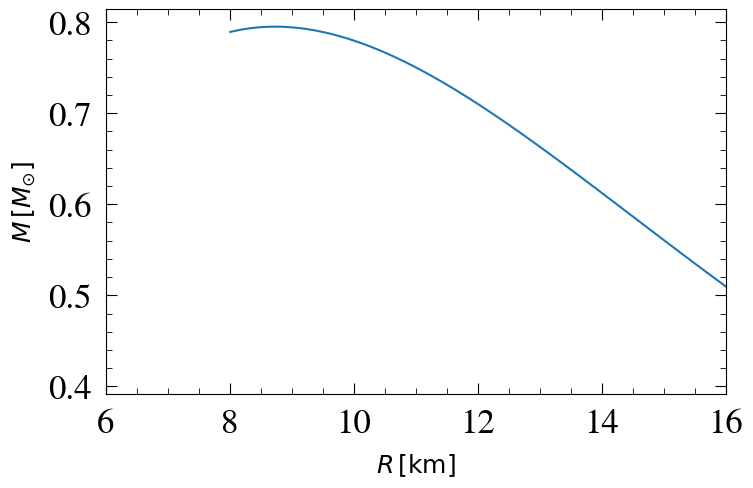

In [ ]:
eos=EOS('neutron.txt')
rhoc_list = 10** np.linspace(max(lg(2e14), lg(eos.min_rho*1.1)), lg(eos.max_rho), 50)

M_list = []
M0_list = []
R_list = []

for rhoc in rhoc_list:

    tov = star(eos, rhoc)
    M_list.append(tov.M / M_sun)
    M0_list.append(tov.M0 / M_sun)
    R_list.append(tov.R / km)


plt.plot(R_list,M_list)
plt.minorticks_on()
plt.xlim(6,16)

plt.xlabel(r'$R\,[\rm km]$')
plt.ylabel(r'$M\,[M_{\odot}]$')

## In Oppenheimer-Volkoff paper, the maximal mass is $\sim 0.7\,M_{\odot}$, why the mass we obtained is slightly larger?


Explain:

Inside a neutron star, the equation of state is primarily determined by neutron degeneracy pressure. The relationship between pressure $P$ and density  $\rho$ depends on whether the neutrons are non-relativistic, semi-relativistic, or ultra-relativistic.


At relatively low densities, neutrons behave non-relativistically, meaning their kinetic energy is much smaller than their rest mass energy $E_k \ll mc^2 $. In this case, the pressure follows a polytropic relation:

$$
P \propto \rho^{5/3}
$$

This is a **stiff** equation of state

As density increases, the neutrons become relativistic, meaning their kinetic energy becomes comparable to their rest mass energy . In this intermediate regime, the effective polytropic index decreases gradually from $5/3$ toward $4/3$, making the equation of state softer.

In our approximation, we assume that the neutrons are nonrelativistic, so the EOS is stiffer than Oppenheimer & Volkoff's calculations, which leads to larger maximal mass

---
Neglecting strong interactions leads to an underestimate of the maximum mass of neutron stars. Observationally, neutron stars typically have masses around $1.35,M_\odot$, and the most massive ones measured so far are close to $2,M_\odot$, which sets a lower bound on the maximum mass that a realistic neutron-star EOS must support.

A variety of EOS models have been proposed based on different theoretical approaches. Each EOS leads to a different mass–radius relation and predicts a different maximum mass. In the following, we will examine several theory-based EOSs and study their corresponding mass–radius relations.

---

In [ ]:
eos=EOS('AP4.txt')
tov =star(eos,0.9089e15)
print(tov.M/M_sun,tov.M0/M_sun,tov.R/km)

1.4000771059233603 1.571435974069302 11.41715303598411


Text(0, 0.5, '$M\\,[M_{\\odot}]$')

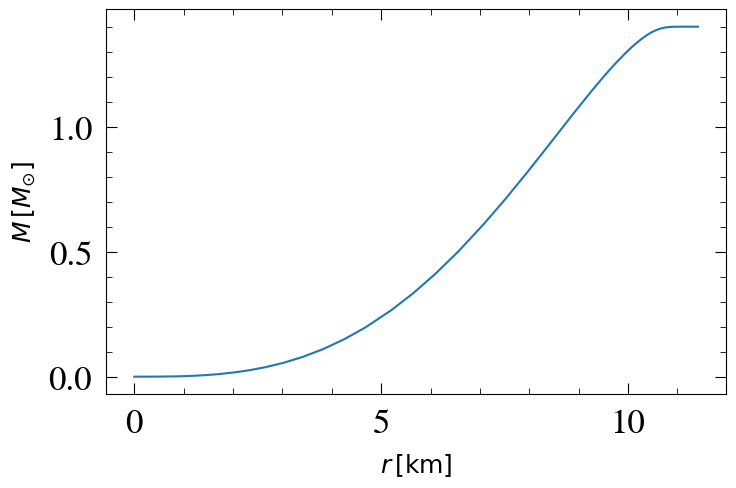

In [ ]:
plt.plot(tov.rsol/km,tov.msol/M_sun)
plt.minorticks_on()
plt.xlabel(r'$r\,[\rm km]$')
plt.ylabel(r'$M\,[M_{\odot}]$')

Text(0, 0.5, '$p\\,[\\rm erg/cm^3$')

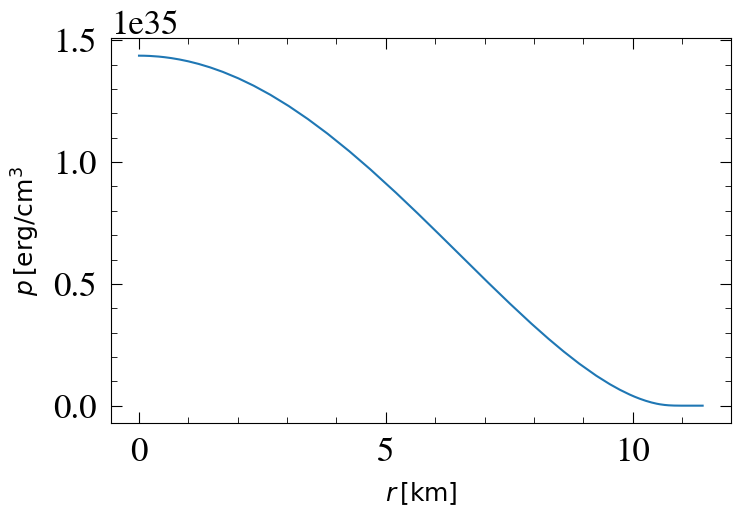

In [ ]:
plt.plot(tov.rsol/km,tov.psol)
plt.minorticks_on()
plt.xlabel(r'$r\,[\rm km]$')
plt.ylabel(r'$p\,[\rm erg/cm^3$')

Text(0, 0.5, '$\\rm metric \\ function$')

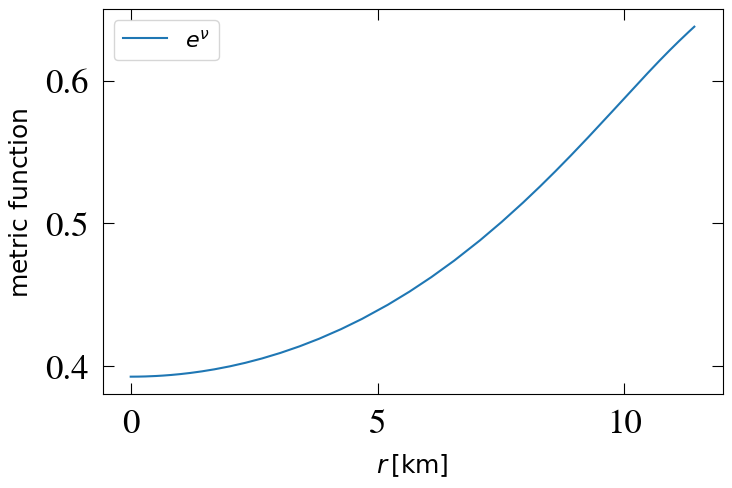

In [ ]:
plt.plot(tov.rsol/km,np.e**(tov.nusol),label=r'$e^{\nu}$')
plt.legend()
plt.xlabel(r'$r\,[\rm km]$')
plt.ylabel(r'$\rm metric \ function$')

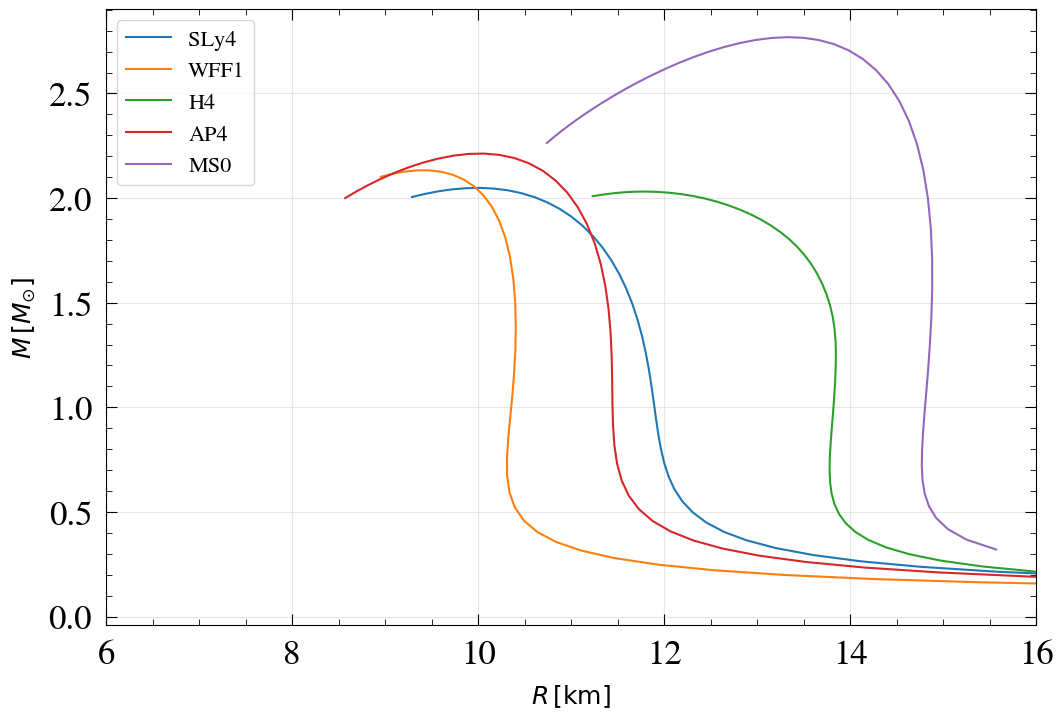

In [ ]:
names = ["SLy4.txt","WFF1.txt","H4.txt","AP4.txt","MS0.txt"]

plt.figure(figsize=(12,8))

for name in names:

    eos = EOS(name)

    rhoc_list = 10**np.linspace(
        max(lg(2e14), lg(eos.min_rho*1.1)),
        lg(eos.max_rho),
        50
    )

    M_list = []
    M0_list = []
    R_list = []

    for rhoc in rhoc_list:

        tov = star(eos, rhoc)

        M_list.append(tov.M / M_sun)
        M0_list.append(tov.M0 / M_sun)
        R_list.append(tov.R / km)


    label = name.replace(".txt","")
    plt.plot(R_list, M_list, label=label)

plt.minorticks_on()
plt.xlim(6,16)
plt.xlabel(r'$R\,[\rm km]$')
plt.ylabel(r'$M\,[M_{\odot}]$')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Binding energy

# redshift on the surface of NS
$$
\boxed{
z = \left(1-\frac{2GM}{Rc^2}\right)^{-1/2}-1 .
}
$$